# Europe 2026 catalogue: brief-paper figures

Builds the four figures for a short paper describing
`data/heatwave_events_europe_2026.csv`, the 32-event CTX90pct catalogue from
`scripts/detect_heatwaves_europe.py`. Each writes a PDF to `plots/detection/`.

| Figure | File | Shows |
|---|---|---|
| 1 | `europe_2026_fig1_map.pdf` | Where the events were, over heat-wave days per cell |
| 2 | `europe_2026_fig2_timeline.pdf` | When they ran across the season |
| 3 | `europe_2026_fig3_severity.pdf` | How severity is distributed across the 32 |
| 4 | `europe_2026_fig4_anomaly_vs_tmax.pdf` | Absolute heat against heat relative to local climate |

Runs on CPU in the repo `.venv`, about 15 seconds end to end. Needs
`data/era5_europe/europe_tmax_2026.nc` and the cached threshold, both of which
are gitignored, so regenerate them with `scripts/download_era5_europe_daily.py`
and `scripts/detect_heatwaves_europe.py` on a fresh checkout.


**Koppen class** (`koppen`): the climate type most common across the land the
event covered, whose first letter is the `zone` column.

| Code | Zone | Description | Where these events sat | Events |
|---|---|---|---|---|
| `Cfb` | temperate | Oceanic: mild, damp, no dry season | Ireland, Britain, northern France | 9 |
| `Dfb` | cold (continental) | Humid continental with warm summers | Central Europe, western Russia, southern Scandinavia | 8 |
| `Csa` | temperate | Mediterranean with hot, dry summers | Southern Italy, Greece, southern Spain, northern Algeria, Anatolia | 6 |
| `Dfc` | cold (continental) | Subarctic: short cool summers | Northern Norway and Sweden, Arctic Russia | 4 |
| `Csb` | temperate | Mediterranean with milder summers | Northern Portugal, the Spanish interior uplands | 2 |
| `Cfa` | temperate | Humid subtropical: hot summers, rain year round | Western Bulgaria | 1 |
| `Dsb` | cold (continental) | Continental with a dry summer | Eastern Turkish highlands | 1 |
| `BSk` | arid | Cold semi-arid steppe | Interior Algeria | 1 |

That is 18 temperate, 13 cold continental and 1 arid; the domain holds no
tropical or polar land, so two of the five zones never appear.

Two warnings. Five events are not European, 8 and 12 in Algeria and 22, 24 and
26 in Anatolia, and they hold the catalogue's two hottest readings of 49.2C and
48.0C. The top four each span more than 1,000 km from centroid to hottest cell,
so do not name them after one country.

**Centroid** - It is the area-weighted mean position over the cells in the event on its peak day, $\varphi_c=\sum A_{ij}\varphi_i/\sum A_{ij}$, and likewise for longitude.


## Setup

In [30]:
import importlib.util as iu
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm, Normalize

YEAR = 2026
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "heatwave_ic").is_dir())
DATA, PLOTS = ROOT / "data", ROOT / "plots" / "detection"
PLOTS.mkdir(parents=True, exist_ok=True)


def submodule(name):
    """Load one heatwave_ic module directly.

    heatwave_ic/__init__ imports neuralgcm and dinosaur; nothing in this
    notebook needs jax, and the repo .venv has no GPU stack.
    """
    spec = iu.spec_from_file_location(
        name, ROOT / "heatwave_ic" / f"{name}.py")
    mod = iu.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod


# plots.py calls mpl_apply() on import, which is where the project rcParams
# come from (CLAUDE.md). Do not set rcParams here.
D, P = submodule("detect"), submodule("plots")

events = pd.read_csv(DATA / f"heatwave_events_europe_{YEAR}.csv",
                     parse_dates=["start", "peak", "end"])
sev = events["severity_C_km2_day"]
norm = LogNorm(vmin=sev.min(), vmax=sev.max())
cmap = plt.get_cmap("inferno_r")

print(f"{len(events)} events, {events.start.min():%d %b} to {events.end.max():%d %b}")
events.head()

32 events, 01 May to 05 Sep


,rank,event_id,start,peak,end,duration_days,peak_area_km2,mean_area_km2,centroid_lat,centroid_lon,peak_tmax_C,peak_tmax_lat,peak_tmax_lon,max_anom_C,mean_anom_C,severity_C_km2_day,n_cell_days,koppen,zone
0,1,30,2026-06-12,2026-06-27,2026-07-03,22,2980025,1459992,48.91,13.63,43.59,44.25,-1.00,14.13,3.66,116787848,62275,Dfb,cold (continental)
1,2,66,2026-07-27,2026-08-13,2026-08-19,24,1962045,1063281,44.96,4.41,42.71,38.00,-4.00,11.11,2.66,66910770,47625,Dfb,cold (continental)
2,3,12,2026-05-20,2026-05-26,2026-06-02,14,2054782,1195894,45.29,6.78,39.03,39.25,-8.00,11.06,3.05,50322167,30505,Cfb,temperate
3,4,49,2026-06-30,2026-07-12,2026-07-24,25,1179162,700106,46.75,4.75,43.60,38.00,13.00,10.81,2.85,49600074,31565,Cfb,temperate
4,5,6,2026-05-14,2026-05-19,2026-05-22,9,1300042,814909,57.03,37.63,33.67,50.00,40.75,10.36,3.21,23100489,17898,Dfb,cold (continental)


## The catalogue

All 32 events with the columns that describe what kind of heat each one was,
and where. The two temperature columns disagree on purpose: `peak_tmax_C` is an
absolute reading and `max_anom_C` is degrees past the local threshold, so the
hottest event and the most extreme-for-its-place event are not the same row.
Figure 4 is this table as a picture.

In [31]:
# Country of the CENTROID, read off the coordinates by hand: there is no
# country dataset in the repo and no offline geocoder in the .venv, and a
# lookup this size beats adding a dependency for one column. Grouped by
# country so the per-country counts are readable.
#
# It labels the balance point, not the extent. Events 1 to 4 each stretch more
# than 1,000 km from centroid to hottest cell and span several countries, so
# read this column as "where the event sat", never as "the country's heat wave".
CENTROID_COUNTRY = {rank: country for country, ranks in {
    "Russia":   (5, 7, 15, 16, 18, 21, 31),
    "France":   (2, 3, 4, 28),
    "UK":       (9, 10, 11, 14),
    "Turkey":   (22, 24, 26),
    "Algeria":  (8, 12),
    "Ireland":  (17, 19),
    "Spain":    (27, 30),
    "Sweden":   (13, 29),
    "Bulgaria": (32,),
    "Germany":  (1,),
    "Greece":   (20,),
    "Italy":    (6,),
    "Norway":   (25,),
    "Portugal": (23,),
}.items() for rank in ranks}

glance = events.assign(country=events["rank"].map(CENTROID_COUNTRY))[
    ["rank", "country", "zone", "koppen", "duration_days", "severity_C_km2_day", "mean_anom_C", "peak_tmax_C",
     "peak_tmax_lat", "peak_tmax_lon", "max_anom_C", "mean_anom_C"]]

assert glance.country.notna().all(), "a rank is missing from CENTROID_COUNTRY"
# print(glance.to_string(index=False))
glance

,rank,country,zone,koppen,duration_days,severity_C_km2_day,mean_anom_C,peak_tmax_C,peak_tmax_lat,peak_tmax_lon,max_anom_C,mean_anom_C
0,1,Germany,cold (continental),Dfb,22,116787848,3.66,43.59,44.25,-1.00,14.13,3.66
1,2,France,cold (continental),Dfb,24,66910770,2.66,42.71,38.00,-4.00,11.11,2.66
2,3,France,temperate,Cfb,14,50322167,3.05,39.03,39.25,-8.00,11.06,3.05
3,4,France,temperate,Cfb,25,49600074,2.85,43.60,38.00,13.00,10.81,2.85
4,5,Russia,cold (continental),Dfb,9,23100489,3.21,33.67,50.00,40.75,10.36,3.21
5,6,Italy,temperate,Csa,18,20033734,2.45,42.72,41.25,15.75,8.71,2.45
6,7,Russia,cold (continental),Dfb,10,16069613,2.36,31.73,49.75,41.25,6.60,2.36
7,8,Algeria,temperate,Csa,16,8786466,2.95,47.98,36.75,7.50,10.26,2.95
8,9,UK,temperate,Cfb,13,8734033,3.10,34.31,52.50,0.00,9.21,3.10
9,10,UK,temperate,Cfb,7,5788552,4.56,36.58,51.50,-2.75,11.73,4.56


## Figure 1: where the events were

The shading is the number of days each grid cell spent inside any detected
event, so all 32 contribute to it. `scripts/detect_heatwaves_europe.py` saves
the event table but discards `det.labels`, so the detection is rerun here
rather than read back. On this domain that costs about four seconds, which is
cheaper than maintaining a cache file.

The script's own version of this map labels only the 8 most severe events, and
its labels collide in southeast France. This one numbers all 32 and moves the
dates into a key.

In [32]:
target = D.open_daily_tmax([DATA / "era5_europe" / f"europe_tmax_{YEAR}.nc"])
thresh = xr.open_dataarray(
    DATA / f"heatwave_threshold_europe_1991_2020_p90.nc").load()
land = D.land_mask_for(target["latitude"].values, target["longitude"].values)
det = D.detect(target, thresh, land_mask=land,
               min_days=3, min_area_km2=50_000.0)
hw_days = (det.labels > 0).sum(axis=0)

print(f"{det.n_events} blobs before the area filter; "
      f"busiest cell spent {hw_days.max()} days in an event")

103 blobs before the area filter; busiest cell spent 80 days in an event


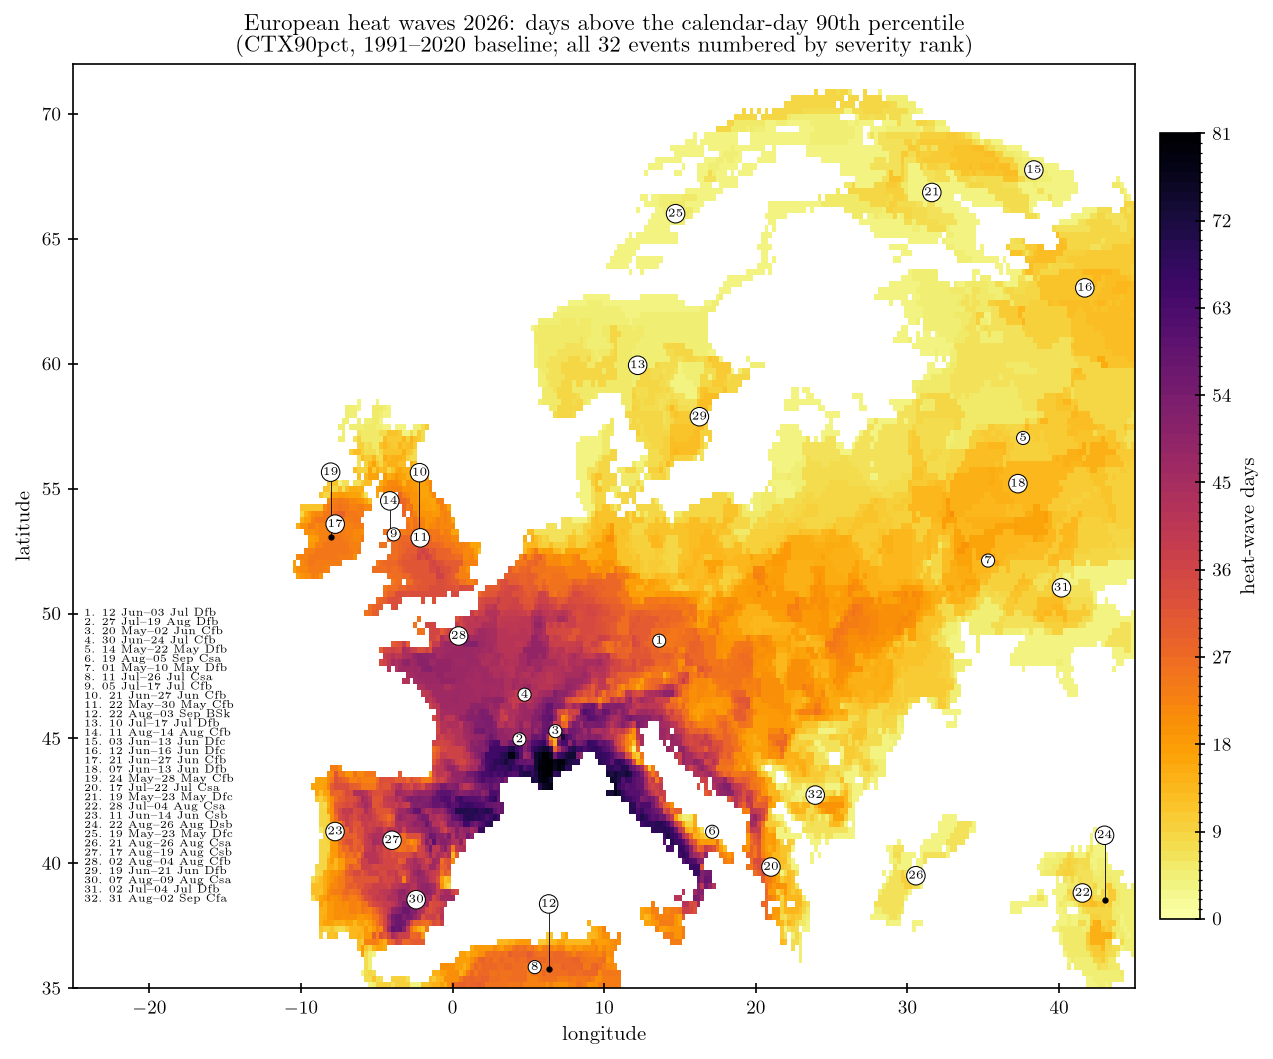

In [33]:
# top_n=0 draws the shaded map with no annotations. The paper's numbering
# and key are added below so all 32 events appear, not the default 8.
fig, ax = P.plot_europe_heatwaves(hw_days, det.lat, det.lon, events=events,
                                  top_n=0, year=YEAR)

# ponytail: greedy nudge, O(n^2) over 32 points. Swap for a real label solver
# only if the catalogue grows past a few hundred events.
placed = []
for _, e in events.iterrows():
    x, y = e.centroid_lon, e.centroid_lat
    while any(abs(x - px) < 1.7 and abs(y - py) < 1.3 for px, py in placed):
        y += 1.3
    placed.append((x, y))
    if y != e.centroid_lat:          # leader line back to the true centroid
        ax.plot([e.centroid_lon, x], [e.centroid_lat, y], color="black",
                linewidth=0.4, zorder=4)
    ax.scatter([e.centroid_lon], [e.centroid_lat], s=4, c="black", zorder=5)
    ax.annotate(str(int(e["rank"])), (x, y), fontsize=5.5, zorder=6,
                ha="center", va="center", color="black",
                bbox=dict(boxstyle="circle,pad=0.13", facecolor="white",
                          edgecolor="black", linewidth=0.5))

ax.set_title(f"European heat waves {YEAR}: days above the calendar-day "
             f"90th percentile\n(CTX90pct, 1991--2020 baseline; all "
             f"{len(events)} events numbered by severity rank)")

# Event key, parked in the empty Atlantic rather than outside the axes, which
# would otherwise leave a third of the canvas white.
key = [f"{int(e['rank']):2d}. {e.start:%d %b}--{e.end:%d %b} {e.koppen}"
       for _, e in events.iterrows()]
ax.text(-24.3, 50.2, "\n".join(key), fontsize=5.0, va="top", ha="left",
        linespacing=1.5, zorder=7)

fig.savefig(PLOTS / f"europe_{YEAR}_fig1_map.pdf", bbox_inches="tight")

## Figure 1b: the same map with country borders

Figure 1 carries no borders, which is honest about the data (the detector never
sees a country) but makes it hard to say where an event was. This draws the same
shading over national outlines so the events can be read off by country.

The outlines are Natural Earth 1:50m, clipped to the domain and rounded to two
decimals, which is 318 KB of plain GeoJSON in `data/`. Drawing them is a loop
over rings, so the notebook still needs no cartopy or geopandas.

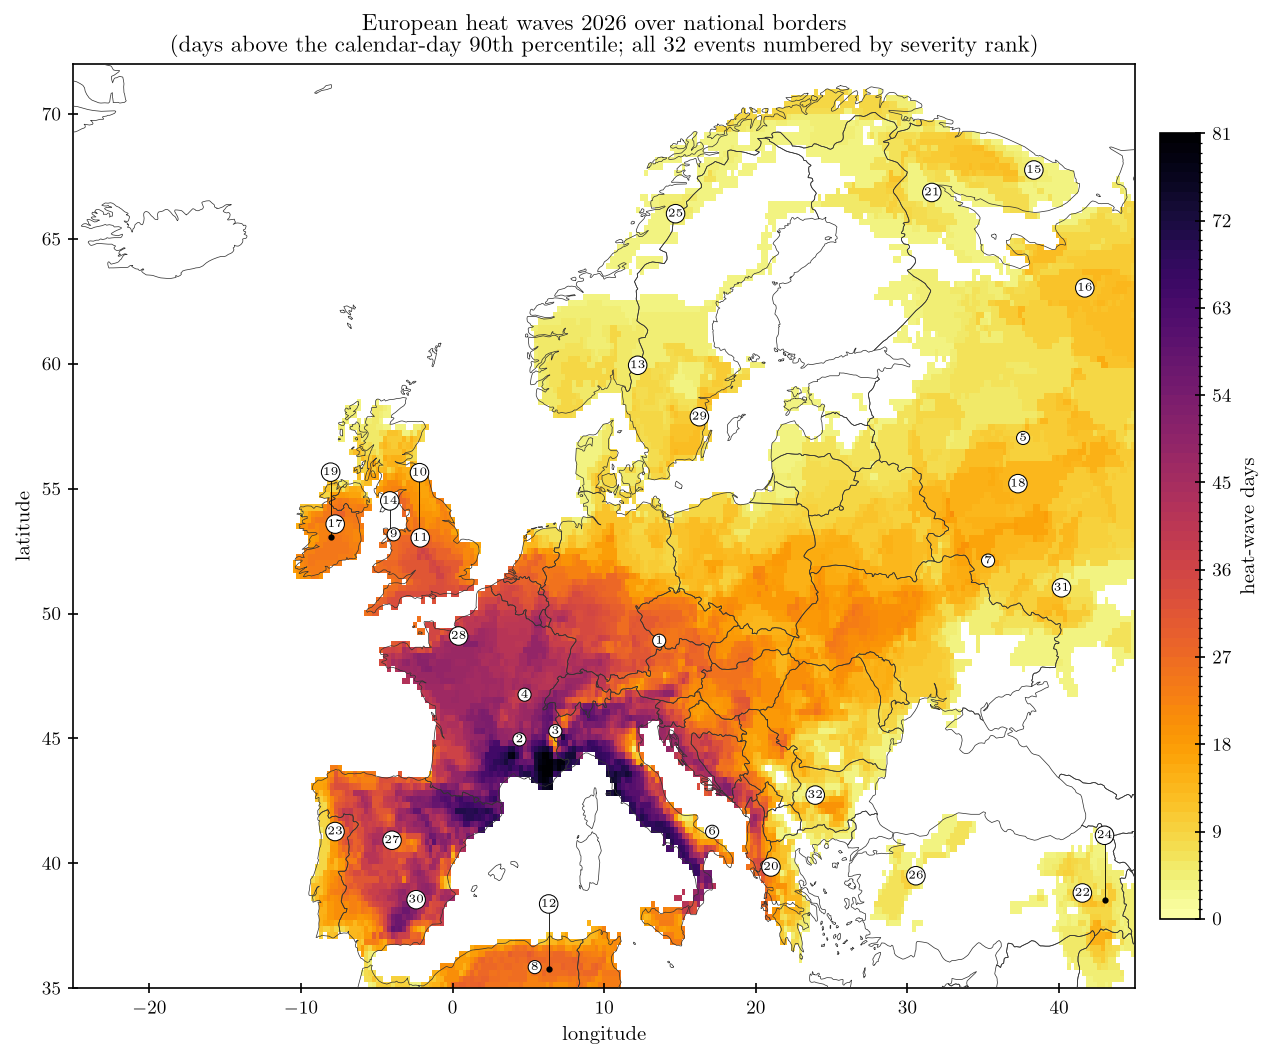

In [39]:
import json
import urllib.request

BORDERS = DATA / "borders_europe_ne50m.json"
if not BORDERS.exists():          # one-off fetch, ~3 MB down, 318 KB kept
    SRC = ("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/"
           "master/geojson/ne_50m_admin_0_countries.geojson")
    W, S, E, N = -25.0, 35.0, 45.0, 72.0
    with urllib.request.urlopen(SRC, timeout=60) as r:
        world = json.load(r)
    rings = []
    for feat in world["features"]:
        geom = feat["geometry"]
        raw = (geom["coordinates"] if geom["type"] == "Polygon"
               else [r for poly in geom["coordinates"] for r in poly])
        for ring in raw:
            xs, ys = [p[0] for p in ring], [p[1] for p in ring]
            if max(xs) < W or min(xs) > E or max(ys) < S or min(ys) > N:
                continue          # ring lies wholly outside the domain
            rings.append([[round(x, 2), round(y, 2)] for x, y in ring])
    BORDERS.write_text(json.dumps(rings, separators=(",", ":")))
    print(f"fetched {len(rings)} rings -> {BORDERS}")

rings = json.loads(BORDERS.read_text())

fig, ax = P.plot_europe_heatwaves(hw_days, det.lat, det.lon, events=events,
                                  top_n=0, year=YEAR)
for ring in rings:
    ax.plot([p[0] for p in ring], [p[1] for p in ring],
            color="#333333", linewidth=0.35, zorder=3)

# Same numbering as Figure 1, so the two read together.
placed = []
for _, e in events.iterrows():
    x, y = e.centroid_lon, e.centroid_lat
    while any(abs(x - px) < 1.7 and abs(y - py) < 1.3 for px, py in placed):
        y += 1.3
    placed.append((x, y))
    if y != e.centroid_lat:
        ax.plot([e.centroid_lon, x], [e.centroid_lat, y], color="black",
                linewidth=0.4, zorder=4)
    ax.scatter([e.centroid_lon], [e.centroid_lat], s=4, c="black", zorder=5)
    ax.annotate(str(int(e["rank"])), (x, y), fontsize=5.5, zorder=6,
                ha="center", va="center", color="black",
                bbox=dict(boxstyle="circle,pad=0.13", facecolor="white",
                          edgecolor="black", linewidth=0.5))

ax.set_xlim(det.lon.min(), det.lon.max())
ax.set_ylim(det.lat.min(), det.lat.max())
ax.set_title(f"European heat waves {YEAR} over national borders\n"
             f"(days above the calendar-day 90th percentile; all "
             f"{len(events)} events numbered by severity rank)")

fig.savefig(
    PLOTS / f"europe_{YEAR}_fig1b_map_borders.pdf", bbox_inches="tight")

## Figure 2: when they ran

One bar per event from start to end, ordered by start date, shaded by severity.
The tick inside each bar is the peak day, the day with the highest mean
exceedance across the cells the event covered.

This is the figure that shows overlap: events that share a fortnight but not a
region are separate rows here and separate blobs on Figure 1.

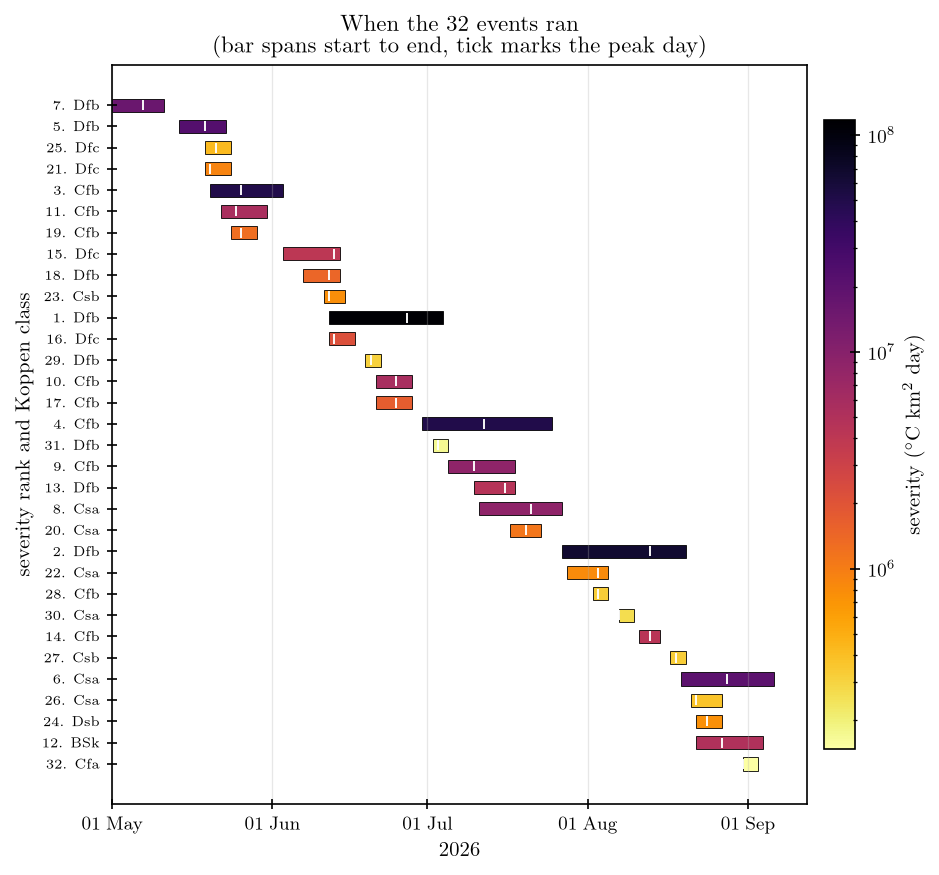

In [35]:
season = events.sort_values("start").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(7.2, 6.4))
for y, (_, e) in enumerate(season.iterrows()):
    ax.barh(y, e.end - e.start + pd.Timedelta(days=1), left=e.start,
            height=0.62, color=cmap(norm(e.severity_C_km2_day)),
            edgecolor="black", linewidth=0.4)
    ax.plot(e.peak, y, marker="|", color="white", ms=5, mew=0.9, zorder=4)

ax.set_yticks(range(len(season)))
ax.set_yticklabels([f"{int(e['rank'])}. {e.koppen}"
                    for _, e in season.iterrows()], fontsize=6.5)
ax.invert_yaxis()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.grid(axis="x", alpha=0.3, linewidth=0.6)
ax.set(xlabel=f"{YEAR}", ylabel="severity rank and Koppen class",
       title=f"When the {len(events)} events ran\n"
       f"(bar spans start to end, tick marks the peak day)")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax,
             label=r"severity ($^\circ$C km$^2$ day)", pad=0.02, shrink=0.85)

fig.savefig(PLOTS / f"europe_{YEAR}_fig2_timeline.pdf", bbox_inches="tight")

## Figure 3: how severity is distributed?

Severity spans three orders of magnitude, so the bars need a log axis; on a
linear one the top event is the only visible bar. The blue curve is the
cumulative share, and it is the number to quote: it tells a reader how far down
the catalogue they need to go before the rest stops mattering.

**Severity** (`severity_C_km2_day`): the total excess heat an event delivered,
one number for how much of Europe was how far past normal for how long, so it
ranks events by overall burden and not by how hot it got anywhere.

$$S=\sum_{(t,i,j)\,\in\,E}\bigl[T_{\max}(t,i,j)-T_{90}(d_t,i,j)\bigr]\,A(i)$$

$E$ is the set of cell-days in the event, $T_{90}$ is that cell's 90th
percentile for that calendar day over 1991--2020, and $A(i)$ is the cell's area.

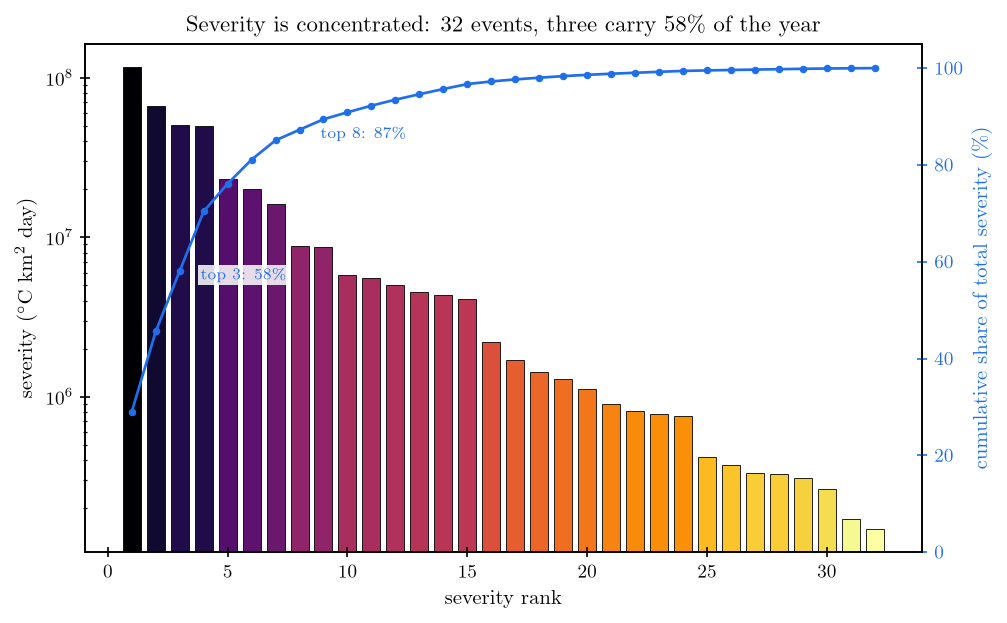

In [36]:
cum = 100 * sev.cumsum() / sev.sum()

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.bar(events["rank"], sev, color=cmap(norm(sev)), edgecolor="black",
       linewidth=0.4, width=0.75)
ax.set_yscale("log")
ax.set(xlabel="severity rank", ylabel=r"severity ($^\circ$C km$^2$ day)",
       title=f"Severity is concentrated: {len(events)} events, "
       f"three carry {cum.iloc[2]:.0f}\\% of the year")

ax2 = ax.twinx()
ax2.plot(events["rank"], cum, color="#1f6feb", marker="o", ms=2.6, lw=1.3)
ax2.set_ylabel(r"cumulative share of total severity (\%)", color="#1f6feb")
ax2.tick_params(axis="y", colors="#1f6feb")
ax2.set_ylim(0, 105)
ax2.grid(False)
for k in (3, 8):
    ax2.annotate(f"top {k}: {cum.iloc[k - 1]:.0f}\\%", (k, cum.iloc[k - 1]),
                 xytext=(10, -4), textcoords="offset points", fontsize=7.5,
                 color="#1f6feb", bbox=dict(facecolor="white", alpha=0.85,
                                            edgecolor="none", pad=1.2))

fig.savefig(PLOTS / f"europe_{YEAR}_fig3_severity.pdf", bbox_inches="tight")

## Figure 4: absolute heat against relative heat

`peak_tmax_C` is a temperature and `max_anom_C` is degrees above that cell's own
calendar-day 90th percentile. They rank the catalogue differently, and this
figure is how a reader decides which column their question needs. Colour is the
centroid latitude, so the north-south structure is visible directly.

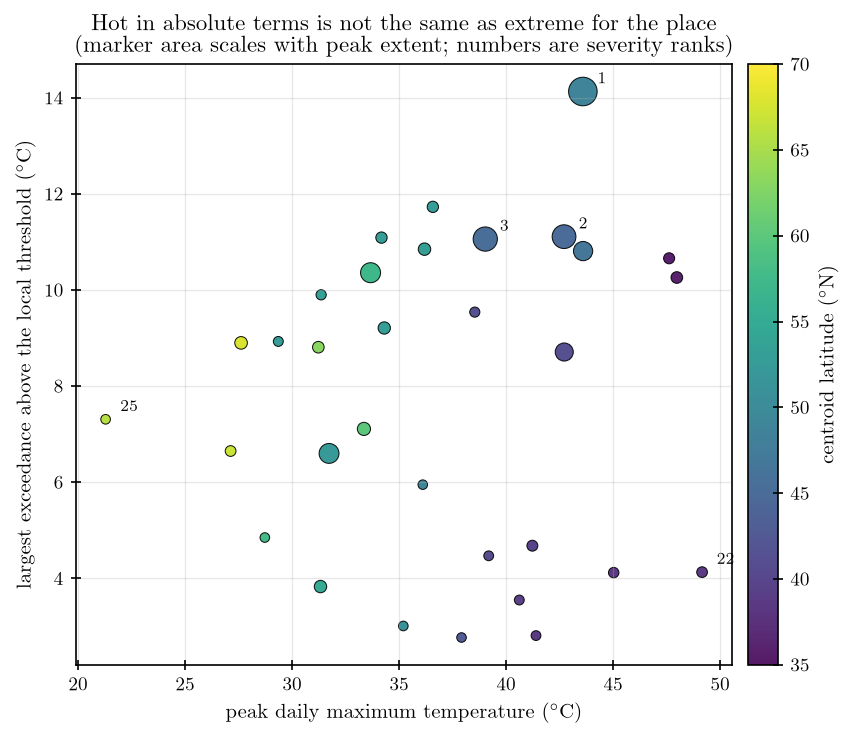

In [37]:
fig, ax = plt.subplots(figsize=(6.8, 5.2))
sc = ax.scatter(events.peak_tmax_C, events.max_anom_C,
                s=18 + 170 * events.peak_area_km2 / events.peak_area_km2.max(),
                c=events.centroid_lat, cmap="viridis", norm=Normalize(35, 70),
                edgecolor="black", linewidth=0.5, alpha=0.9)
fig.colorbar(sc, ax=ax, label=r"centroid latitude ($^\circ$N)", pad=0.02)

# Label the three most severe plus whichever events sit at the extremes of
# each axis, since those are the ones the caption argues about.
notable = set(events.nsmallest(3, "rank")["rank"]) | {
    int(events.loc[events.max_anom_C.idxmax(), "rank"]),
    int(events.loc[events.peak_tmax_C.idxmax(), "rank"]),
    int(events.loc[events.peak_tmax_C.idxmin(), "rank"])}
for _, e in events.iterrows():
    if int(e["rank"]) in notable:
        ax.annotate(int(e["rank"]), (e.peak_tmax_C, e.max_anom_C),
                    xytext=(7, 4), textcoords="offset points", fontsize=7.5)

ax.grid(alpha=0.3, linewidth=0.6)
ax.set(xlabel=r"peak daily maximum temperature ($^\circ$C)",
       ylabel=r"largest exceedance above the local threshold ($^\circ$C)",
       title="Hot in absolute terms is not the same as extreme for the place\n"
             "(marker area scales with peak extent; numbers are severity ranks)")

fig.savefig(PLOTS / f"europe_{YEAR}_fig4_anomaly_vs_tmax.pdf",
            bbox_inches="tight")

## Interesting
### Figure 5: which climates the catalogue is made of

The glossary table as a picture, counted two ways. Counting events says the
catalogue is mostly oceanic; weighting by severity says it is mostly humid
continental. Both are true, and the gap between the panels is the point: the
common climate type here produced many modest events, while a less common one
produced the few that dominate the year.

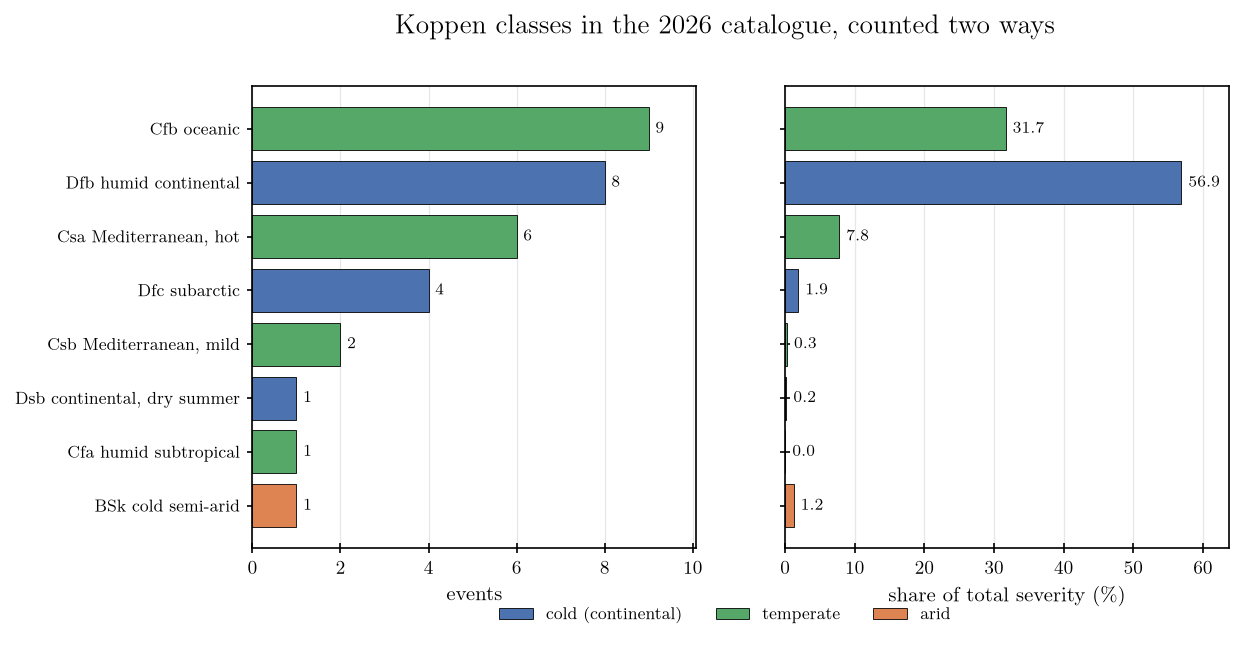

In [38]:
SHORT = {"Cfb": "oceanic", "Dfb": "humid continental",
         "Csa": "Mediterranean, hot", "Dfc": "subarctic",
         "Csb": "Mediterranean, mild", "Cfa": "humid subtropical",
         "Dsb": "continental, dry summer", "BSk": "cold semi-arid"}
ZONE_COLOR = {"cold (continental)": "#4C72B0", "temperate": "#55A868",
              "arid": "#DD8452"}

by_class = (events.groupby(["koppen", "zone"])
            .agg(n=("rank", "size"), severity=("severity_C_km2_day", "sum"))
            .reset_index().sort_values("n"))
by_class["share"] = 100 * by_class.severity / sev.sum()
colors = [ZONE_COLOR[z] for z in by_class.zone]
y = np.arange(len(by_class))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.4, 4.0), sharey=True)
a1.barh(y, by_class.n, color=colors, edgecolor="black", linewidth=0.4)
a1.set(xlabel="events", xticks=range(0, 11, 2))
for yi, n in zip(y, by_class.n):
    a1.text(n + 0.15, yi, str(n), va="center", fontsize=7.5)

a2.barh(y, by_class.share, color=colors, edgecolor="black", linewidth=0.4)
a2.set(xlabel=r"share of total severity (\%)")
for yi, s in zip(y, by_class.share):
    a2.text(s + 1.0, yi, f"{s:.1f}", va="center", fontsize=7.5)

a1.set_yticks(y)
a1.set_yticklabels([f"{k}  {SHORT[k]}" for k in by_class.koppen], fontsize=8)
for ax_ in (a1, a2):
    ax_.grid(axis="x", alpha=0.3, linewidth=0.6)
    ax_.set_axisbelow(True)
    ax_.margins(x=0.12)

handles = [plt.Rectangle((0, 0), 1, 1, facecolor=c, edgecolor="black",
                         linewidth=0.4) for c in ZONE_COLOR.values()]
fig.legend(handles, ZONE_COLOR.keys(), loc="lower center", ncol=3,
           frameon=False, fontsize=8, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Koppen classes in the 2026 catalogue, counted two ways", y=1.0)

fig.savefig(PLOTS / f"europe_{YEAR}_fig5_koppen.pdf", bbox_inches="tight")